In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve,auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib
import streamlit as st

In [ ]:
df = pd.read_csv('dataset.csv')
df.head()



,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,1/1/2019 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,1/1/2019 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,1/1/2019 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,1/1/2019 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,1/1/2019 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
#df['dob'] = pd.to_datetime(df['dob'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
#df['year'] = df['trans_date_trans_time'].dt.year


In [ ]:
drop_columns = ['Unnamed: 0' , 'trans_date_trans_time' , 'first','last', 'street', 'city','state', 'zip', 'job', 'dob', 'trans_num']
df = df.drop(columns = drop_columns)

In [ ]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month
0,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1
1,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1
2,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1
3,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1
4,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1


In [ ]:
cat_col = ['merchant', 'category', 'gender']

encoders= {}
for col in cat_col:
  encoders[col] = LabelEncoder()
  df[col]=encoders[col].fit_transform(df[col])

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    return np.array([geodesic((a,b),(c,d)).km for a ,b,c,d in zip(lat1,lon1,lat2,lon2)])

df['distance'] = haversine(df['lat'],df['long'],df['merch_lat'],df['merch_long'])

In [ ]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,2.703190e+15,514,8,4.97,0,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,78.773821
1,6.304230e+11,241,4,107.23,0,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,30.216618
2,3.885950e+13,390,0,220.11,1,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,108.102912
3,3.534090e+15,360,2,45.00,1,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,95.685115
4,3.755340e+14,297,9,41.96,1,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,77.702395


In [ ]:
features= ['merchant', 'category','amt','cc_num', 'hour', 'day', 'month', 'gender', 'distance']
x =df[features]
y = df['is_fraud']

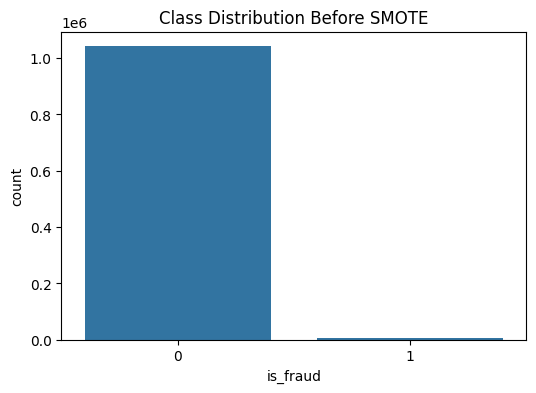

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x= 'is_fraud', data = df)
plt.title("Class Distribution Before SMOTE")
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
x_resample, y_resample = smote.fit_resample(x,y)

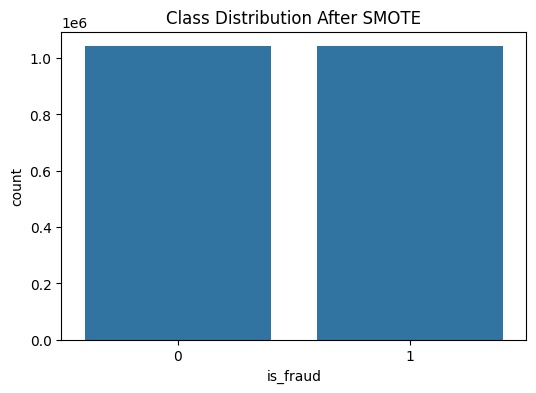

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x= y_resample)
plt.title("Class Distribution After SMOTE")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size=0.2 , random_state= 42)


In [ ]:
lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    is_unbalance=True,
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.05,
    n_estimators=200,
)
lgb_model.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 833653, number of negative: 834457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1103
[LightGBM] [Info] Number of data points in the train set: 1668110, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499759 -> initscore=-0.000964
[LightGBM] [Info] Start training from score -0.000964


LGBMClassifier(is_unbalance=True, learning_rate=0.05, metric='auc',
               n_estimators=200, objective='binary')

In [ ]:
y_pred = lgb_model.predict(x_test)


In [ ]:
print("Classification Report: \n", classification_report(y_test, y_pred))
print("ROC Accuracy Score: ", roc_auc_score(y_test, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.97      0.95    208112
           1       0.97      0.92      0.95    208916

    accuracy                           0.95    417028
   macro avg       0.95      0.95      0.95    417028
weighted avg       0.95      0.95      0.95    417028

ROC Accuracy Score:  0.9473597754217395


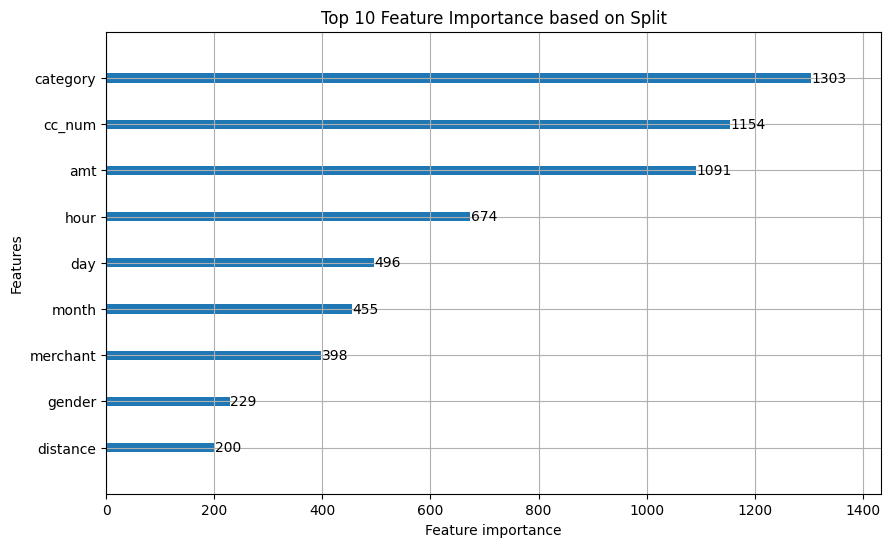

In [ ]:
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='split', figsize=(10,6))
plt.title("Top 10 Feature Importance based on Split")
plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, lgb_model.predict_proba(x_test)[:,1])
roc_auc = auc(fpr, tpr)

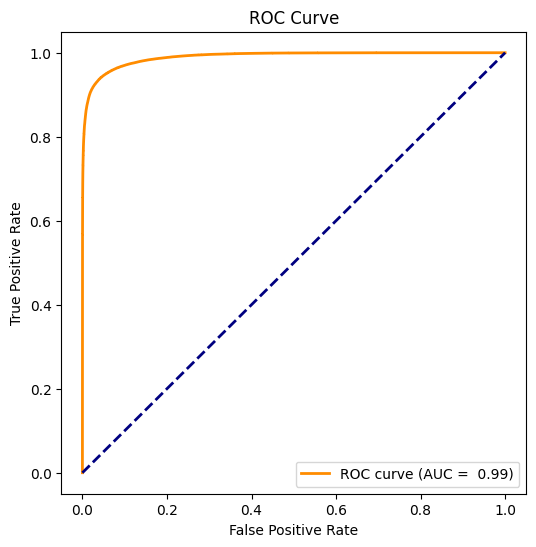

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc: .2f})' )

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [ ]:
joblib.dump(lgb_model, "fraud_detection_model.jb")
joblib.dump(encoders, "label_encoder.jb")

['label_encoder.jb']